In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
import joblib
import itertools
import matplotlib.pyplot as plt

# Leer los archivos CSV
df_pinza = pd.read_csv("DATASETTOMAPINZA.csv")
df_cerrada = pd.read_csv("DATASETTOMACERRADA.csv")
df_anular = pd.read_csv("DATASETTOMAANULAR.csv")
df_pulgar = pd.read_csv("DATASETTOMAPULGAR.csv")
df_corazon = pd.read_csv("DATASETTOMACORAZON.csv")
df_indice = pd.read_csv("DATASETTOMAINDICE.csv")
df_abierta = pd.read_csv("DATASETTOMAABIERTA.csv")

# Crear un nuevo DataFrame vacío
abs_df = pd.DataFrame()

# Concatenar las columnas específicas de cada DataFrame
abs_df["MAV_total"] = pd.concat([
    df_cerrada['MAV_total'], 
    df_pinza['MAV_total'], 
    df_anular['MAV_total'], 
    df_pulgar['MAV_total'], 
    df_corazon['MAV_total'], 
    df_indice['MAV_total'], 
    df_abierta['MAV_total']
], axis=0).reset_index(drop=True)

abs_df["VAR_total"] = pd.concat([
    df_cerrada['VAR_total'], 
    df_pinza['VAR_total'], 
    df_anular['VAR_total'], 
    df_pulgar['VAR_total'], 
    df_corazon['VAR_total'], 
    df_indice['VAR_total'], 
    df_abierta['VAR_total']
], axis=0).reset_index(drop=True)

abs_df["RMS_total"] = pd.concat([
    df_cerrada['RMS_total'], 
    df_pinza['RMS_total'], 
    df_anular['RMS_total'], 
    df_pulgar['RMS_total'], 
    df_corazon['RMS_total'], 
    df_indice['RMS_total'], 
    df_abierta['RMS_total']
], axis=0).reset_index(drop=True)

# Crear las etiquetas
abs_df["intencion"] = pd.concat([
    df_cerrada['Mano_cerrada'].apply(lambda x: 1),
    df_pinza['Mano_pinza'].apply(lambda x: 2),
    df_anular['Dedo_anular'].apply(lambda x: 3),
    df_pulgar['Dedo_pulgar'].apply(lambda x: 4),
    df_corazon['Dedo_corazon'].apply(lambda x: 5),
    df_indice['Dedo_indice'].apply(lambda x: 6),
    df_abierta['Mano_abierta'].apply(lambda x: 0)
], axis=0).reset_index(drop=True)

# Separar las características (X) y la etiqueta (y)
X = abs_df.drop("intencion", axis=1)
y = abs_df["intencion"]

# Dividir los datos en conjuntos de entrenamiento y prueba (70% entrenamiento, 30% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar los datos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Entrenar el modelo de regresión logística
logreg = LogisticRegression(max_iter=1000, multi_class='ovr')
logreg.fit(X_train, y_train)

# Hacer predicciones
y_pred = logreg.predict(X_test)

# Evaluar el modelo
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Guardar el modelo entrenado
joblib.dump(logreg, 'modelo_entrenado.pkl')


[[20  0  0  0  0  0  0]
 [ 0  4 14  6  0  1  0]
 [ 1  0 19  2  0  0  0]
 [ 0  0  0 18  0  1  2]
 [10  0  2  2  1  0  5]
 [ 0  0  0  4  1  2  7]
 [ 0  0  0  2  0  0 16]]
              precision    recall  f1-score   support

           0       0.65      1.00      0.78        20
           1       1.00      0.16      0.28        25
           2       0.54      0.86      0.67        22
           3       0.53      0.86      0.65        21
           4       0.50      0.05      0.09        20
           5       0.50      0.14      0.22        14
           6       0.53      0.89      0.67        18

    accuracy                           0.57       140
   macro avg       0.61      0.57      0.48       140
weighted avg       0.63      0.57      0.49       140



['modelo_entrenado.pkl']

[[29  0  0  0  1  0  2]
 [ 0 13 11  6  3  1  1]
 [ 0  7 19  4 10  2  0]
 [ 0  4 12 23  0  2  1]
 [ 0  6 10  2 23  1  1]
 [ 0  7  2  6  0 29  2]
 [ 0  9  3  3  5  4 16]]
              precision    recall  f1-score   support

           0       1.00      0.91      0.95        32
           1       0.28      0.37      0.32        35
           2       0.33      0.45      0.38        42
           3       0.52      0.55      0.53        42
           4       0.55      0.53      0.54        43
           5       0.74      0.63      0.68        46
           6       0.70      0.40      0.51        40

    accuracy                           0.54       280
   macro avg       0.59      0.55      0.56       280
weighted avg       0.58      0.54      0.55       280

Confusion matrix, without normalization
Normalized confusion matrix


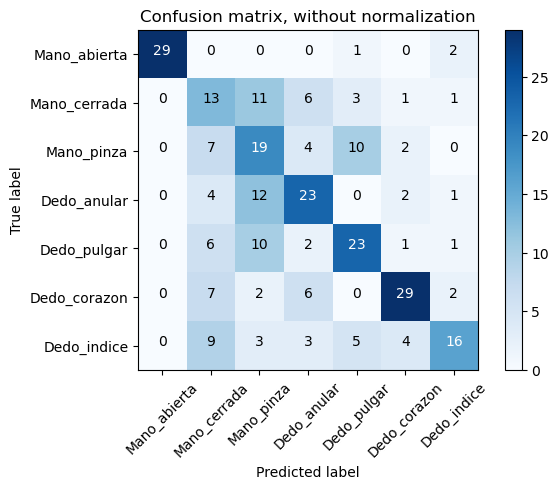

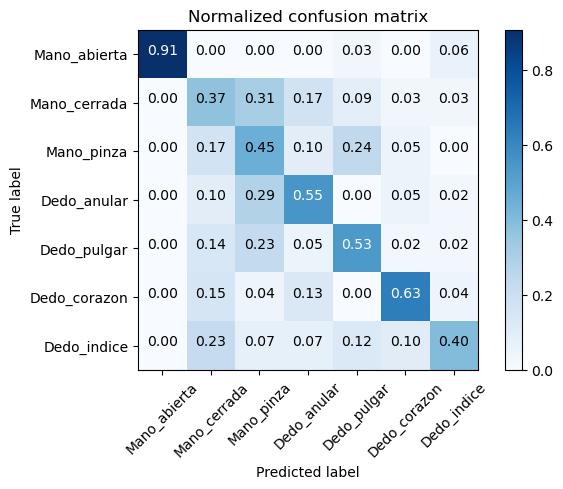

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
import joblib
import itertools
import matplotlib.pyplot as plt

# Leer los archivos CSV
df_pinza = pd.read_csv("DATASETTOMAPINZA.csv")
df_cerrada = pd.read_csv("DATASETTOMACERRADA.csv")
df_anular = pd.read_csv("DATASETTOMAANULAR.csv")
df_pulgar = pd.read_csv("DATASETTOMAPULGAR.csv")
df_corazon = pd.read_csv("DATASETTOMACORAZON.csv")
df_indice = pd.read_csv("DATASETTOMAINDICE.csv")
df_abierta = pd.read_csv("DATASETTOMAABIERTA.csv")

# Crear un nuevo DataFrame vacío
abs_df = pd.DataFrame()

# Concatenar las columnas específicas de cada DataFrame
abs_df["MAV_total"] = pd.concat([
    df_cerrada['MAV_total'], 
    df_pinza['MAV_total'], 
    df_anular['MAV_total'], 
    df_pulgar['MAV_total'], 
    df_corazon['MAV_total'], 
    df_indice['MAV_total'], 
    df_abierta['MAV_total']
], axis=0).reset_index(drop=True)

abs_df["VAR_total"] = pd.concat([
    df_cerrada['VAR_total'], 
    df_pinza['VAR_total'], 
    df_anular['VAR_total'], 
    df_pulgar['VAR_total'], 
    df_corazon['VAR_total'], 
    df_indice['VAR_total'], 
    df_abierta['VAR_total']
], axis=0).reset_index(drop=True)

abs_df["RMS_total"] = pd.concat([
    df_cerrada['RMS_total'], 
    df_pinza['RMS_total'], 
    df_anular['RMS_total'], 
    df_pulgar['RMS_total'], 
    df_corazon['RMS_total'], 
    df_indice['RMS_total'], 
    df_abierta['RMS_total']
], axis=0).reset_index(drop=True)

# Crear las etiquetas
abs_df["intencion"] = pd.concat([
    df_cerrada['Mano_cerrada'].apply(lambda x: 1),
    df_pinza['Mano_pinza'].apply(lambda x: 2),
    df_anular['Dedo_anular'].apply(lambda x: 3),
    df_pulgar['Dedo_pulgar'].apply(lambda x: 4),
    df_corazon['Dedo_corazon'].apply(lambda x: 5),
    df_indice['Dedo_indice'].apply(lambda x: 6),
    df_abierta['Mano_abierta'].apply(lambda x: 0)
], axis=0).reset_index(drop=True)

# Separar las características (X) y la etiqueta (y)
X = abs_df.drop("intencion", axis=1)
y = abs_df["intencion"]

# Dividir los datos en conjuntos de entrenamiento y prueba (70% entrenamiento, 30% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar los datos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Entrenar el modelo k-NN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Hacer predicciones
y_pred = knn.predict(X_test)

# Evaluar el modelo
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Guardar el modelo entrenado
joblib.dump(knn, 'modelo_knn_entrenado.pkl')

# Función para plotear la matriz de confusión
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    Esta función imprime y dibuja la matriz de confusión.
    La normalización se puede aplicar configurando `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Calcular la matriz de confusión
cnf_matrix = confusion_matrix(y_test, y_pred)
np.set_printoptions(precision=2)

# Plotear la matriz de confusión no normalizada
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['Mano_abierta', 'Mano_cerrada', 'Mano_pinza', 'Dedo_anular', 'Dedo_pulgar', 'Dedo_corazon', 'Dedo_indice'],
                      title='Confusion matrix, without normalization')

# Plotear la matriz de confusión normalizada
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['Mano_abierta', 'Mano_cerrada', 'Mano_pinza', 'Dedo_anular', 'Dedo_pulgar', 'Dedo_corazon', 'Dedo_indice'], normalize=True,
                      title='Normalized confusion matrix')

plt.show()


[[20  0  0  0  0  0  0]
 [ 0 11  9  3  1  1  0]
 [ 0  6 14  1  1  0  0]
 [ 0  0  3 13  2  3  0]
 [ 0  3  3  0 11  1  2]
 [ 0  1  0  4  1  7  1]
 [ 0  0  0  0  6  1 11]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       0.52      0.44      0.48        25
           2       0.48      0.64      0.55        22
           3       0.62      0.62      0.62        21
           4       0.50      0.55      0.52        20
           5       0.54      0.50      0.52        14
           6       0.79      0.61      0.69        18

    accuracy                           0.62       140
   macro avg       0.64      0.62      0.63       140
weighted avg       0.63      0.62      0.62       140

Confusion matrix, without normalization
Normalized confusion matrix


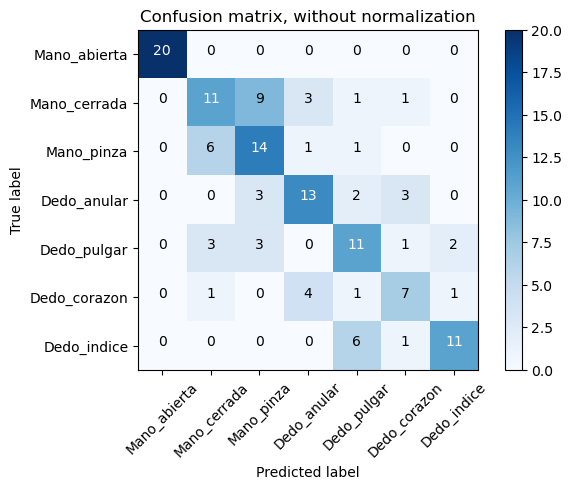

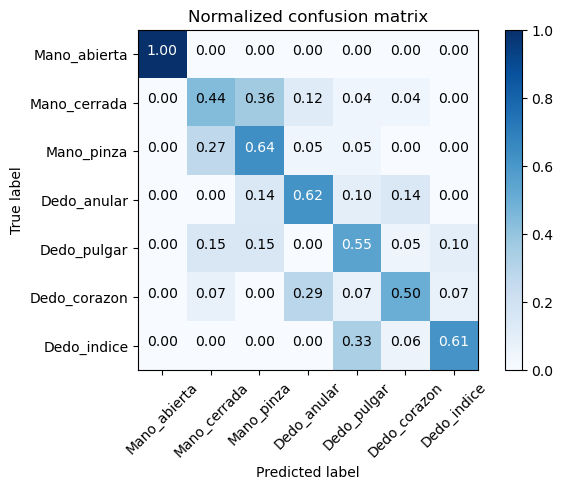

[[20  0  0  0  0  0  0]
 [ 0 11  9  3  1  1  0]
 [ 0  6 14  1  1  0  0]
 [ 0  0  3 13  2  3  0]
 [ 0  3  3  0 11  1  2]
 [ 0  1  0  4  1  7  1]
 [ 0  0  0  0  6  1 11]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       0.52      0.44      0.48        25
           2       0.48      0.64      0.55        22
           3       0.62      0.62      0.62        21
           4       0.50      0.55      0.52        20
           5       0.54      0.50      0.52        14
           6       0.79      0.61      0.69        18

    accuracy                           0.62       140
   macro avg       0.64      0.62      0.63       140
weighted avg       0.63      0.62      0.62       140



In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report
import joblib
import itertools
import matplotlib.pyplot as plt

# Función para plotear la matriz de confusión
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    Esta función imprime y dibuja la matriz de confusión.
    La normalización se puede aplicar configurando `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Leer los archivos CSV
df_pinza = pd.read_csv("DATASETTOMAPINZA.csv")
df_cerrada = pd.read_csv("DATASETTOMACERRADA.csv")
df_anular = pd.read_csv("DATASETTOMAANULAR.csv")
df_pulgar = pd.read_csv("DATASETTOMAPULGAR.csv")
df_corazon = pd.read_csv("DATASETTOMACORAZON.csv")
df_indice = pd.read_csv("DATASETTOMAINDICE.csv")
df_abierta = pd.read_csv("DATASETTOMAABIERTA.csv")

# Crear un nuevo DataFrame vacío
abs_df = pd.DataFrame()

# Concatenar las columnas específicas de cada DataFrame
abs_df["MAV_total"] = pd.concat([
    df_cerrada['MAV_total'], 
    df_pinza['MAV_total'], 
    df_anular['MAV_total'], 
    df_pulgar['MAV_total'], 
    df_corazon['MAV_total'], 
    df_indice['MAV_total'], 
    df_abierta['MAV_total']
], axis=0).reset_index(drop=True)

abs_df["VAR_total"] = pd.concat([
    df_cerrada['VAR_total'], 
    df_pinza['VAR_total'], 
    df_anular['VAR_total'], 
    df_pulgar['VAR_total'], 
    df_corazon['VAR_total'], 
    df_indice['VAR_total'], 
    df_abierta['VAR_total']
], axis=0).reset_index(drop=True)

abs_df["RMS_total"] = pd.concat([
    df_cerrada['RMS_total'], 
    df_pinza['RMS_total'], 
    df_anular['RMS_total'], 
    df_pulgar['RMS_total'], 
    df_corazon['RMS_total'], 
    df_indice['RMS_total'], 
    df_abierta['RMS_total']
], axis=0).reset_index(drop=True)

# Crear las etiquetas
abs_df["intencion"] = pd.concat([
    df_cerrada['Mano_cerrada'].apply(lambda x: 1),
    df_pinza['Mano_pinza'].apply(lambda x: 2),
    df_anular['Dedo_anular'].apply(lambda x: 3),
    df_pulgar['Dedo_pulgar'].apply(lambda x: 4),
    df_corazon['Dedo_corazon'].apply(lambda x: 5),
    df_indice['Dedo_indice'].apply(lambda x: 6),
    df_abierta['Mano_abierta'].apply(lambda x: 0)
], axis=0).reset_index(drop=True)

# Separar las características (X) y la etiqueta (y)
X = abs_df.drop("intencion", axis=1)
y = abs_df["intencion"]

# Dividir los datos en conjuntos de entrenamiento y prueba (70% entrenamiento, 30% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar los datos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Entrenar el modelo de árbol de decisiones
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

# Hacer predicciones
y_pred = tree.predict(X_test)

# Evaluar el modelo
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Guardar el modelo entrenado
joblib.dump(tree, 'modelo_tree_entrenado.pkl')

# Calcular la matriz de confusión
cnf_matrix = confusion_matrix(y_test, y_pred)
np.set_printoptions(precision=2)

# Plotear la matriz de confusión no normalizada
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['Mano_abierta', 'Mano_cerrada', 'Mano_pinza', 'Dedo_anular', 'Dedo_pulgar', 'Dedo_corazon', 'Dedo_indice'],
                      title='Confusion matrix, without normalization')

# Plotear la matriz de confusión normalizada
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['Mano_abierta', 'Mano_cerrada', 'Mano_pinza', 'Dedo_anular', 'Dedo_pulgar', 'Dedo_corazon', 'Dedo_indice'], 
                      normalize=True,
                      title='Normalized confusion matrix')

plt.show()

# Hacer predicciones
y_pred = tree.predict(X_test)

# Evaluar el modelo
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
